# Approximate NMPC on the Klatt-Engell CSTR

This notebook reproduces the approximate-MPC problem of
[Lueken, Brandner & Lucia (2023)](https://doi.org/10.1016/j.ifacol.2023.10.545)
on the van de Vusse reactor of Klatt & Engell (1998): sample the
infinite-horizon controller into a labeled dataset, fit the policy
with Sobolev training, and run it closed loop against the model.
Each call below shows the function's full set of options.

## Deviations from the paper

- The controller is the infinite-horizon problem (one sampling
  element with drto's terminal segment) in place of the paper's
  20-step horizon with a terminal cost.
- The move penalty is omitted, so the previous action is not an
  input. The policy maps the four states to the two controls, not
  six inputs.
- The concentration setpoints are 0.69939 and 0.59607, a steady
  state the reactor holds, where the paper tracks 0.7 and 0.6, which
  it cannot hold at any temperature.
- Every bound is widened out of reach, where the paper enforces
  eq 20c through 20h. Inside the paper's bounds the exact control
  law is a different smooth function on each active set, joined
  where the derivative jumps, and the sampled derivatives at those
  joins run four orders of magnitude above the rest.
- Every tracking term carries unit weight toward the computed
  equilibrium, where eq 22's Q weights the concentrations alone and
  prices control moves rather than control deviation.
- The sampling design is Sobol rather than uniform, and the box is
  the paper's physical ranges, given outright since the widened
  bounds no longer supply one. The paper caps the reactor
  temperature at 140.
- Each control is scaled by the span its labels occupy, where the
  paper scales by the control bounds (eq 23). Q_dot commands tens of
  kJ/h inside a box thousands wide, and bound scaling made its
  errors nearly free.
- The training runs a cosine-decayed rate (1e-3 to 1e-5) with
  gradient clipping and no fine-tune phase, for a fixed budget,
  keeping the checkpoint with the lowest validation loss. The paper
  trained flat at 1e-4 with early stopping.
- The policy is the network plus the constant offset that returns
  the steady control at the steady state exactly, where the paper
  trains an unconstrained network.

## Assemble the problem

The assembly follows [klatt_engell.ipynb](klatt_engell.ipynb): build
the model, compute the steady targets, set every tracking weight to
one, append the terminal segment, cold start, and assemble the
optimization.

Two changes come first. The concentration setpoints move to a pair the
reactor can hold, because a tracking cost with any residual keeps
improving until a constraint stops it, so an equilibrium sits strictly
inside the bounds only when its target is itself a steady state. Then
every bound is widened out of reach, so no constraint is active
anywhere in the sampled box and the exact control law is one smooth
function rather than a different one on each active set, which is the
target Sobolev training assumes.

The steady solve runs before the weights are set, so it selects the
point to hold on the concentrations alone, and the horizon problem
then prices every state and control deviation from it.

In [1]:
import pyomo.environ as pyo
from pyomo.contrib.solver.common.factory import SolverFactory as SF2
import pyomo_pounce  # registers the pounce solver with Pyomo

import drto
from models.klatt_engell import klatt_engell

m = klatt_engell(N=1, h=0.005, move_penalty=False)

# the steady state the reactor holds at F = 11.0 and Q_dot = -1500, read
# off a steady simulation. A tracking cost with any residual keeps
# improving until a constraint stops it, so the target has to be a
# steady state for the equilibrium to sit anywhere but on a bound
m.ca_sp.set_value(0.69939)
m.cb_sp.set_value(0.59607)

# every bound widened out of reach, so no constraint is ever active and
# the control law is smooth across the whole box. The widths stay
# modest because the training floors each control's scale at a
# thousandth of its bound range
for v, (lo, hi) in ((m.c_a, (0.0, 20.0)), (m.c_b, (0.0, 20.0)),
                    (m.T_R, (0.0, 500.0)), (m.T_K, (0.0, 500.0)),
                    (m.F, (0.0, 1000.0)), (m.Q_dot, (-20000.0, 20000.0))):
    for vd in v.values():
        vd.setlb(lo)
        vd.setub(hi)

# the steady solve runs on the concentration weights alone, which is
# what selects the point to hold
sm = pyo.TransformationFactory("drto.steady_state_optimization").create_using(m)
drto.initialize_steady_state(sm)
res = SF2("pounce").solve(sm)
print("steady solve:", res.termination_condition.name,
      "cost", pyo.value(sm.drto_objective))

reg, reg_s = drto.info(m), drto.info(sm)
for kind in ("steady_state", "steady_state_control"):
    for here, there in zip(reg.declarations(kind), reg_s.declarations(kind)):
        v = there["of"]
        val = pyo.value(next(iter(v.values())) if v.is_indexed() else v)
        here["component"].set_value(val)
        print(f"  {here['component'].name} = {val:.6g}")

# with the equilibrium in the targets, every tracking term carries unit
# weight, so the horizon problem prices all four states and both
# controls and the tail integrand vanishes at the equilibrium
for w in (m.q_ca, m.q_cb, m.q_tr, m.q_tk, m.r_f, m.r_q):
    w.set_value(1.0)

pyo.TransformationFactory("drto.infinite_horizon").apply_to(m, nfe=3, ncp=5)
drto.cold_start_dynamic(m, profile="exponential", time_constant=.3)
pyo.TransformationFactory("drto.dynamic_optimization").apply_to(m)

steady solve: convergenceCriteriaSatisfied cost 4.071417096855543e-12
  ca_sp = 0.699389
  cb_sp = 0.596072
  tr_sp = 138.014
  tk_sp = 136.282
  f_sp = 10.9951
  q_sp = -1501.87


## Generate the data

The dataset holds one solve per Sobol point over the state box, with
the gradient of each first action read from the solve's
factorization.

In [2]:
data = drto.approximate_nmpc_data(
    m,
    n=128,              # draws
    method="sobol",     # "sobol" | "lhs" | "uniform"
    inputs=None,        # Params to sample. Default the initial-condition Params
    ranges={"ca_hat": (0.1, 2.0), "cb_hat": (0.1, 2.0),   # the paper's box,
            "tr_hat": (110.0, 150.0), "tk_hat": (110.0, 140.0)},  # given
                        # explicitly because the default reads the state
                        # bounds, which are now out of reach
    gradients=True,     # store du0/dinput, read from the solve's factorization
    solver="pounce",
    seed=0,
    path="models/data/klatt_engell.json",
)
print(data)

drto approximate-NMPC dataset: points 128, failures 0, method sobol, inputs ca_hat, cb_hat, tr_hat, tk_hat


## The sampling

The Sobol points cover the box evenly. The panels are the
concentration and temperature coordinates of the drawn initial
states.

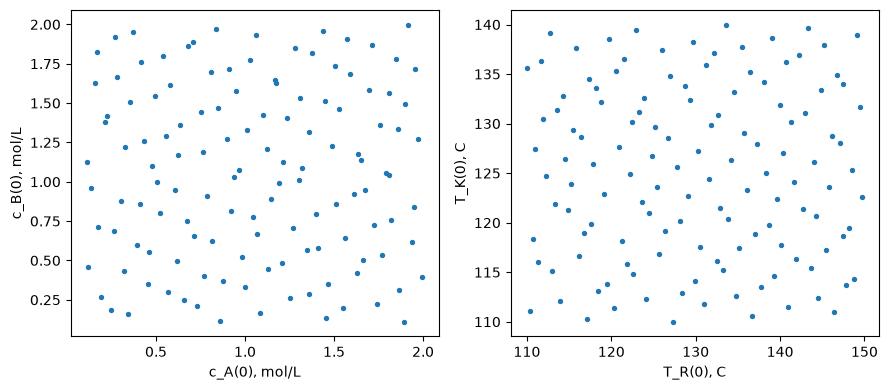

In [3]:
import json
import matplotlib.pyplot as plt

pts = json.load(open("models/data/klatt_engell.json"))["points"]
fig, (a, b) = plt.subplots(1, 2, figsize=(9, 4))
a.scatter([p["x"]["ca_hat"] for p in pts], [p["x"]["cb_hat"] for p in pts], s=8)
a.set_xlabel("c_A(0), mol/L")
a.set_ylabel("c_B(0), mol/L")
b.scatter([p["x"]["tr_hat"] for p in pts], [p["x"]["tk_hat"] for p in pts], s=8)
b.set_xlabel("T_R(0), C")
b.set_ylabel("T_K(0), C")
fig.tight_layout()

## Train the policy

The training minimizes the Sobolev loss (eq 17 of the paper) under
the cosine schedule, the inputs scaled by their boxes and the
controls by their labels' span:

$$L = \frac{1}{N m}\sum_{i=1}^{N} \|\hat u_i - u_i\|^2
+ \frac{\gamma}{N m d}\sum_{i=1}^{N} \|\hat J_i - J_i\|_F^2$$

$\hat u_i$ is the policy's output at point $i$, $u_i$ the label,
$\hat J_i, J_i$ the scaled Jacobians, $m$ the number of controls, and
$d$ the number of inputs. The subscript $F$ is the Frobenius norm,
the root sum of squares of a matrix's entries, so the second sum is
the mean squared error over every entry of the Jacobian. With
`steady_state_enforced` the policy is the network $N$ plus the
constant offset that pins the equilibrium:

$$\hat u(x) = u_{ss} + N(x) - N(x_{ss})$$

The two network terms cancel at $x = x_{ss}$, so the policy returns
the steady control at the steady state exactly, whatever the weights.

That offset also bounds the policy's distance from the steady control
by a class $\mathcal{K}_\infty$ function of the state's distance from
the steady state, meaning a continuous, strictly increasing function
that is zero at zero and grows without bound. Every layer of $N$ is an
affine map followed by $\tanh$, and both are Lipschitz, so the
composition is Lipschitz on the sampled box, meaning some finite $L$
satisfies $\|N(x) - N(x')\| \le L\|x - x'\|$ for every pair of states
in it. Setting $x' = x_{ss}$ in the offset form gives

$$\|\hat u(x) - u_{ss}\| = \|N(x) - N(x_{ss})\| \le L\,\|x - x_{ss}\|$$

and $\alpha(r) = L r$ is such a function. The policy's action
therefore approaches the steady control continuously as the state
approaches the steady state, with no offset left at the equilibrium.
A nonzero `weight_decay` penalizes the weights' size, which lowers
$L$.

In [4]:
data = drto.ApproximateNmpcDataset.load("models/data/klatt_engell.json")
policy = drto.approximate_nmpc_train(
    data,               # dataset, or a path
    validation=0.2,     # dataset, path, or a fraction split off `data`
    validation_loss="sobolev",  # "sobolev" scores validation on the
                        # training loss. "value" is the value error alone
    training_loss="sobolev",  # "sobolev" adds the gradient term to the
                        # value error. "value" fits the values alone
    gamma=1,
    hidden=(16,16),
    activation="tanh",
    steady_state_enforced=True,  # the policy returns the steady control
                        # at the steady state exactly
    lr=1e-3,
    schedule="cosine",  # "cosine" decays to lr_min. "flat" holds lr
    lr_min=1e-5,
    clip=1.0,           # gradient-norm cap. None disables
    weight_decay=0,   # AdamW's decoupled L2 penalty on the weights. 0 disables
    epochs=50000,
    fine_tune=0,      # final fraction trained on the value error alone
    seeds=1,            # networks trained. The best by validation is kept
    device="auto",
)

# the policy is callable in model units, and round-trips through a file
print(policy({"ca_hat": 0.8, "cb_hat": 0.5, "tr_hat": 134.1, "tk_hat": 130.0}))
policy.save("models/data/klatt_engell_policy.pt")

{'F': 14.079599165828554, 'Q_dot': -1501.848516019391}


## The training history

The run records the per-epoch training and validation losses. The
kept weights are those at the validation curve's minimum.

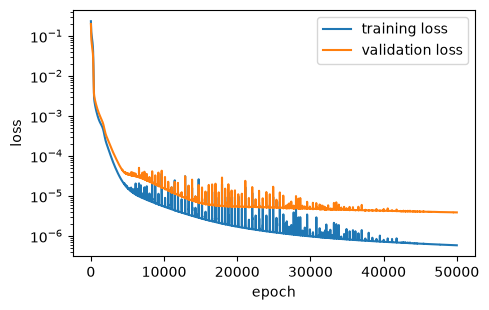

In [5]:
axes = drto.plot_history(policy)

## The fit

Each panel plots the policy's action against the solver's label for
one control, on the line where the two agree. The training split
comes from the policy itself, which records which points it held out,
and each series carries its coefficient of determination.

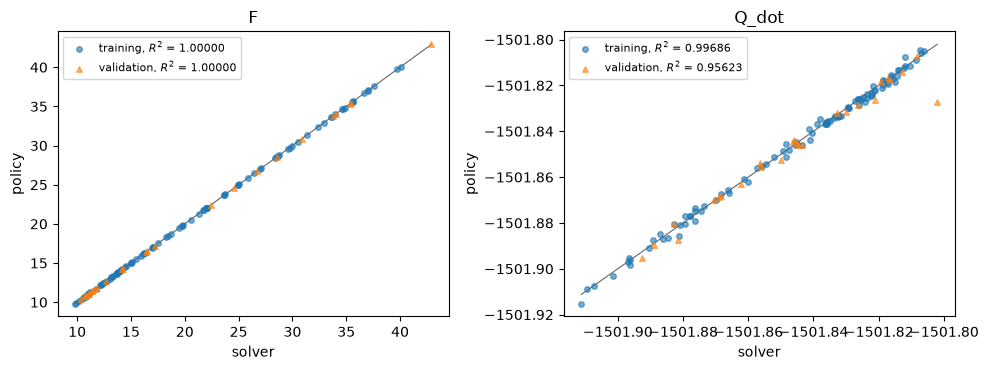

In [6]:
axes = drto.plot_parity(policy, data)

## Run it closed loop

The policy steers the model one sampling interval at a time.
`compare` also solves the horizon problem at each visited state, so
the report records the horizon solve's control beside the policy's at
the same states, which the control plot draws as the NMPC comparison.

In [7]:
policy = drto.ApproximateNMPC.load("models/data/klatt_engell_policy.pt")
report = drto.approximate_nmpc_closed_loop(
    policy, m,
    samples=100,         # closed-loop steps
    x0={"c_a": .75, "c_b": .75, "T_R": 120.0, "T_K": 120.0},            # initial state. Default the initial-condition Params' values
    disturbances=None,  # realization per step, one value per sample
    solver="pounce",
    compare=True,       # also solve at each visited state. Record the solver's control
)
print(report)

drto approximate-NMPC closed loop: 100 samples, closed-loop cost 6111.78 (the stage cost summed over the visited samples). States c_a, c_b, T_R, T_K. Moves F, Q_dot. The solver's controls are recorded at the visited states


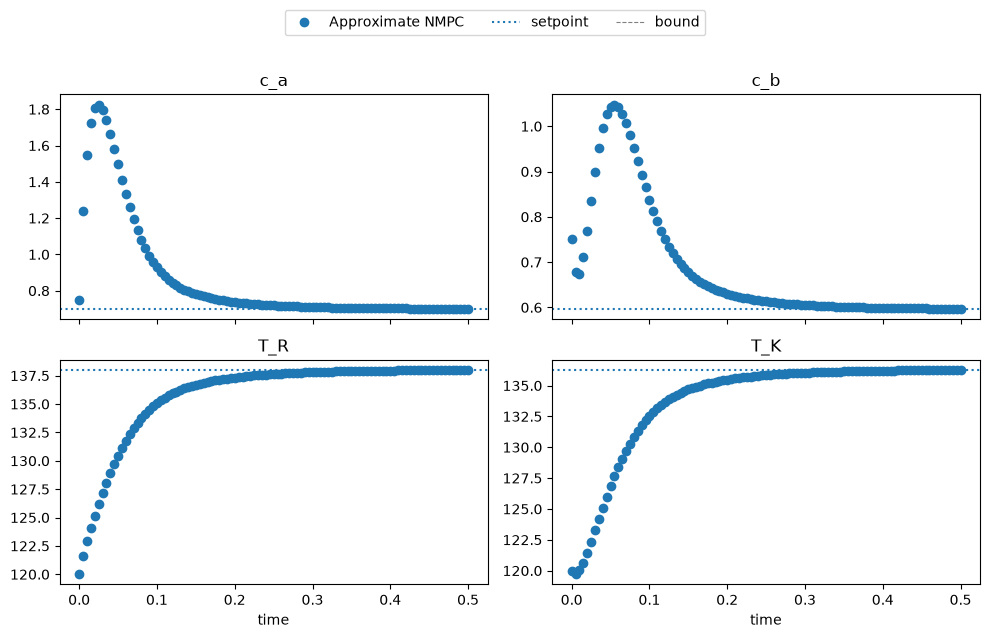

In [8]:
axes = drto.plot_states(report)

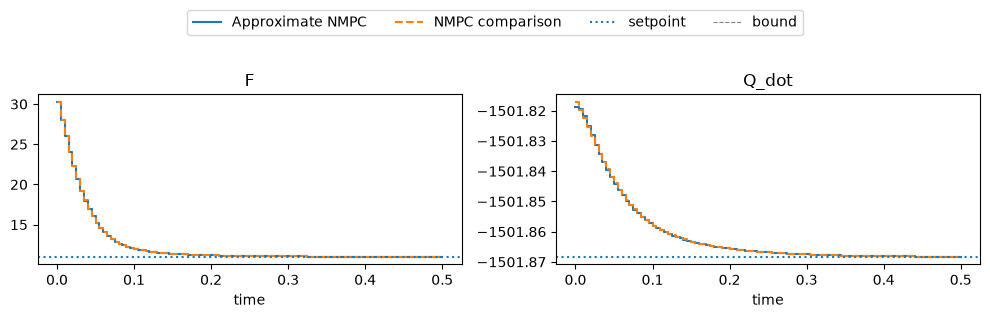

In [9]:
axes = drto.plot_controls(report)